In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import joblib


In [2]:
# ✅ Load Loan Dataset
df = pd.read_csv("/content/final_loan_dataset.csv")

print("✅ Dataset Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())


✅ Dataset Loaded Successfully!
Shape: (20000, 19)
   person_age person_gender person_education  person_income  person_emp_exp  \
0          28          male           Master          73201               8   
1          23          male        Associate          23628               0   
2          24          male        Associate          38624               4   
3          22        female        Associate          20194               0   
4          27          male        Associate          71689               3   

  person_home_ownership  loan_amnt      loan_intent  monthly_interest_rate  \
0              MORTGAGE       2500  HOMEIMPROVEMENT               0.009175   
1                  RENT       4000        EDUCATION               0.013017   
2                  RENT      13500          VENTURE               0.011192   
3                  RENT       4000        EDUCATION               0.011125   
4                   OWN      24250          MEDICAL               0.009575   

      

In [3]:
print("\n✅ Loan Status Count:")
print(df["loan_status"].value_counts())

print("\n✅ Target Classes:")
print(df["loan_status"].unique())



✅ Loan Status Count:
loan_status
Rejected    10000
Approved    10000
Name: count, dtype: int64

✅ Target Classes:
['Rejected' 'Approved']


In [4]:
# ✅ Monthly Interest Rate
df["monthly_interest_rate"] = df["loan_int_rate"] / 12 / 100

# ✅ Monthly Income
df["monthly_income"] = df["person_income"] / 12

# ✅ EMI Approximation
df["emi"] = df["loan_amnt"] * df["monthly_interest_rate"]

# ✅ Debt-to-Income Ratio
df["dti"] = df["emi"] / df["monthly_income"]

# ✅ Loan Burden (% Income)
df["loan_percent_income"] = df["loan_amnt"] / df["person_income"]

print("\n✅ Feature Engineering Completed!")



✅ Feature Engineering Completed!


In [19]:
df.drop(columns=["loan_status_num"], inplace=True)

In [20]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]


categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("\nCategorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)



Categorical Columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
Numerical Columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'monthly_interest_rate', 'emi', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'monthly_income', 'dti']


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [22]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced"
    ))
])


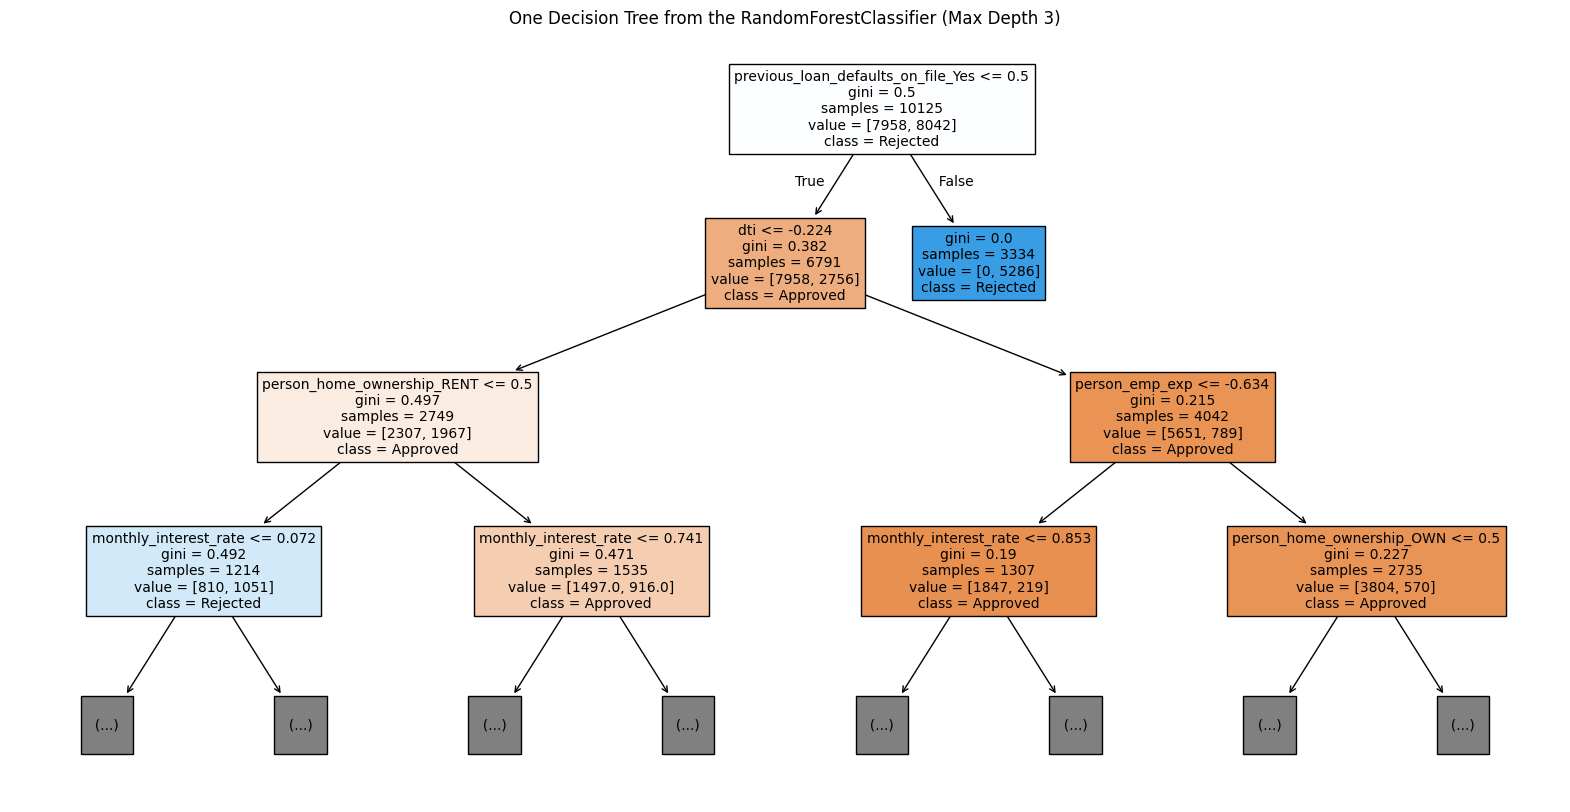

In [28]:
import matplotlib.pyplot as plt
from sklearn import tree

# Get the RandomForestClassifier from the pipeline
rf_classifier = model.named_steps['classifier']

# Get one individual decision tree from the forest
single_tree = rf_classifier.estimators_[0]

# Get feature names from the preprocessor
numeric_features = numerical_cols
categorical_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
categorical_features_ohe = list(categorical_encoder.get_feature_names_out(categorical_cols))

# Combine all feature names in the order they are processed
feature_names = numeric_features + categorical_features_ohe

# Plot the tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    single_tree,
    feature_names=feature_names,
    class_names=rf_classifier.classes_,
    filled=True,
    max_depth=3, # Limit depth for better visualization
    fontsize=10
)
plt.title("One Decision Tree from the RandomForestClassifier (Max Depth 3)")
plt.show()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [25]:
model.fit(X_train, y_train)
print("\n✅ Model Training Completed!")



✅ Model Training Completed!


In [29]:
y_pred = model.predict(X_test)

print("\n✅ Accuracy Score:", accuracy_score(y_test, y_pred))

print("\n✅ Classification Report:")
print(classification_report(y_test, y_pred))



✅ Accuracy Score: 0.90425

✅ Classification Report:
              precision    recall  f1-score   support

    Approved       0.89      0.93      0.91      2000
    Rejected       0.92      0.88      0.90      2000

    accuracy                           0.90      4000
   macro avg       0.91      0.90      0.90      4000
weighted avg       0.91      0.90      0.90      4000



In [30]:
joblib.dump(model, "loan_approval_pipeline.pkl")
print("\n✅ Model Saved Successfully: loan_approval_pipeline.pkl")



✅ Model Saved Successfully: loan_approval_pipeline.pkl


In [31]:
def loan_prediction(sample, title="Test Case"):

    # ✅ Predict Probabilities
    prob = model.predict_proba(sample)[0]

    # ✅ Correct Class Order
    reject_prob  = round(prob[0] * 100, 1)
    approve_prob = round(prob[1] * 100, 1)

    # ✅ Extract Key Values
    credit_score = float(sample["credit_score"][0])
    dti = float(sample["dti"][0])
    defaults = str(sample["previous_loan_defaults_on_file"][0]).lower()

    income = float(sample["person_income"][0])
    loan_amount = float(sample["loan_amnt"][0])
    emp_exp = float(sample["person_emp_exp"][0])
    home = str(sample["person_home_ownership"][0]).lower()
    interest = float(sample["loan_int_rate"][0])
    risk_cat = str(sample["credit_risk_category"][0]).lower()

    loan_percent_income = loan_amount / income

    # ✅ Step 1: Threshold Decision
    if approve_prob >= 60:
        decision = "Approved ✅"
    elif reject_prob >= 60:
        decision = "Rejected ❌"
    else:
        decision = "Borderline ⚠️ Manual Review"

    # ✅ Step 2: Hard Rejection Rules Override
    if credit_score < 600:
        decision = "Rejected ❌"
    if dti > 0.50:
        decision = "Rejected ❌"
    if defaults == "yes":
        decision = "Rejected ❌"

    # ✅ Step 3: Reasons + Suggestions
    reasons = []
    suggestions = []

    if decision.startswith("Rejected"):

        # ✅ Credit Score
        if credit_score < 650:
            reasons.append("Low credit score")
            suggestions.append("Improve credit score above 650.")

        # ✅ Debt-to-Income Ratio
        if dti > 0.35:
            reasons.append("High debt-to-income ratio")
            suggestions.append("Reduce existing debts to lower DTI ratio.")

        # ✅ Loan Burden
        if loan_percent_income > 0.40:
            reasons.append("Loan amount too high compared to income")
            suggestions.append("Reduce loan amount or increase income.")

        # ✅ Employment Experience
        if emp_exp < 2:
            reasons.append("Not enough employment experience")
            suggestions.append("Gain stable job experience before applying again.")

        # ✅ High Interest Rate
        if interest > 18:
            reasons.append("Interest rate is too high")
            suggestions.append("Apply for a loan with lower interest rate.")

        # ✅ High Risk Category
        if risk_cat == "high":
            reasons.append("Applicant falls under high credit risk category")
            suggestions.append("Improve financial profile to reduce risk.")

        # ✅ Home Ownership Risk
        if home == "rent":
            reasons.append("Rent-based applicants have higher repayment risk")
            suggestions.append("Provide co-applicant or more financial proof.")

        # ✅ Default History
        if defaults == "yes":
            reasons.append("Previous loan default history")
            suggestions.append("Maintain clean repayment history.")

        # ✅ Final fallback
        if len(reasons) == 0:
            reasons.append("High financial risk profile")
            suggestions.append("Improve credit profile and reduce loan burden.")

    elif decision.startswith("Borderline"):
        reasons.append("Loan application is borderline and needs manual review.")
        suggestions.append("Improve credit score and reduce DTI for stronger approval.")

    # ✅ Print Final Output
    print("\n==============================")
    print("TEST CASE:", title)
    print("==============================")
    print("Decision:", decision)
    print("Approve Probability:", approve_prob, "%")
    print("Reject Probability:", reject_prob, "%")

    if reasons:
        print("\nMain Reasons:")
        for r in reasons:
            print("❌", r)

    if suggestions:
        print("\nSuggestions to Improve:")
        for s in suggestions:
            print("✅", s)


In [43]:
approved_data = pd.DataFrame([{
     "person_age": 26,
        "person_gender": "female",
        "person_education": "Master",
        "person_income": 80000,
        "person_emp_exp": 4,
        "person_home_ownership": "MORTGAGE",

        "loan_amnt": 15000,
        "loan_intent": "DEBTCONSOLIDATION",
        "loan_int_rate": 10.0,

        "cb_person_cred_hist_length": 5,
        "credit_score": 730,

        "previous_loan_defaults_on_file": "no",
        "credit_risk_category": "LOW",

        "monthly_interest_rate": 10/12/100,
        "monthly_income": 80000/12,
        "emi": 400,
        "dti": 0.19,
        "loan_percent_income": 15000/80000
}])


In [44]:
rejected_data = pd.DataFrame([{
    "person_age": 25,
        "person_gender": "male",
        "person_education": "High School",
        "person_income": 18000,
        "person_emp_exp": 1,
        "person_home_ownership": "RENT",

        "loan_amnt": 26000,
        "loan_intent": "PERSONAL",
        "loan_int_rate": 20.0,

        "cb_person_cred_hist_length": 1,
        "credit_score": 500,

        "previous_loan_defaults_on_file": "yes",
        "credit_risk_category": "HIGH",

        "monthly_interest_rate": 20/12/100,
        "monthly_income": 18000/12,
        "emi": 1000,
        "dti": 0.70,
        "loan_percent_income": 26000/18000
}])


In [45]:
loan_prediction(approved_data, "APPROVED APPLICANT ✅")
loan_prediction(rejected_data, "REJECTED APPLICANT ❌")



TEST CASE: APPROVED APPLICANT ✅
Decision: Approved ✅
Approve Probability: 75.2 %
Reject Probability: 24.8 %

TEST CASE: REJECTED APPLICANT ❌
Decision: Rejected ❌
Approve Probability: 50.0 %
Reject Probability: 50.0 %

Main Reasons:
❌ Low credit score
❌ High debt-to-income ratio
❌ Loan amount too high compared to income
❌ Not enough employment experience
❌ Interest rate is too high
❌ Applicant falls under high credit risk category
❌ Rent-based applicants have higher repayment risk
❌ Previous loan default history

Suggestions to Improve:
✅ Improve credit score above 650.
✅ Reduce existing debts to lower DTI ratio.
✅ Reduce loan amount or increase income.
✅ Gain stable job experience before applying again.
✅ Apply for a loan with lower interest rate.
✅ Improve financial profile to reduce risk.
✅ Provide co-applicant or more financial proof.
✅ Maintain clean repayment history.
